In [ ]:
%pip install -q -U huggingface_hub datasets

In [1]:
!python -m pip install tqdm timm

In [30]:
%matplotlib inline

In [1]:
from pathlib import Path
import sys
import os 
import time
from tqdm import tqdm

os.environ["CUDA_VISIBLE_DEVICES"] = '0'

from PIL import Image
import torch
from torchvision import transforms


# uncomment for script
#REPO_ROOT = Path(__file__).resolve().parent 
REPO_ROOT = Path.cwd().resolve().parent
sys.path.append(str(REPO_ROOT / "Instant-GI"))

from generalizable_model.init_net import InitNet

CHECKPOINT = REPO_ROOT / "Instant-GI/checkpoints/epoch_best_ks_3_cupy.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")
transform = transforms.Compose([
    transforms.ToTensor(),
])

def preprocess(path: Path) -> torch.Tensor:
    return transform(Image.open(path).convert("RGB"))

model = InitNet().to(device)

checkpoint = torch.load(CHECKPOINT, map_location=device)
model.load_state_dict(checkpoint["model"])
model.eval()

def load_image(image_path) -> torch.Tensor:
    image_tensor = preprocess(image_path).unsqueeze(0).to(device)

    return image_tensor

def infer(img_t: Path):
    image_tensor = img_t.unsqueeze(0).to(device)
    with torch.no_grad():
        xy, scaling, rotation, color, triangles = model(image_tensor, get_gaussians=True)
    return dict(
        xy=xy.squeeze(0),
        scaling=scaling.squeeze(0),
        rotation=rotation.squeeze(0),
        color=color.squeeze(0),
        triangles=triangles,  # triangles stay on CUDA unless you call .cpu()
    )



/scratch/10968/nelsoner/miniforge3/envs/instant-gi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using: cuda


In [ ]:
def process_recursive(src, dst, exts={'.jpg', '.png', '.jpeg'}):
    src, dst = Path(src), Path(dst)
    # Find all matching files recursively
    files = [p for p in src.rglob('*') if p.suffix.lower() in exts]

    for f in tqdm(files, desc="Processing"):
        # Mirror structure: src/A/B/img.jpg -> dst/A/B/img.pt
        out = dst / f.relative_to(src).with_suffix('.pt')
        out.parent.mkdir(parents=True, exist_ok=True)
        
        try:
            img = load_image(f).squeeze(0)
            torch.save(infer(img), out)
        except Exception as e:
            print(f"Skipped {f.name}: {e}")


IN_DIR = "/work/10968/nelsoner/ls6/2dgs/gsplat/examples/data/360_v2/"
OUT_DIR = "/work/10968/nelsoner/ls6/datasets/360_v2_gs/"

process_recursive(IN_DIR, OUT_DIR)

In [23]:
print("Processing complete!")
sample_path = "/work/10968/nelsoner/ls6/datasets/360_v2_gs/garden/images_4/DSC07956.pt"
sample_img = "/work/10968/nelsoner/ls6/2dgs/gsplat/examples/data/360_v2/garden/images_4/DSC07956.JPG"

print(f"Loading sample from {sample_path}")
sample = torch.load(sample_path)
# prints out all details to understand structure

print(sample.keys())
# dict_keys(['xy', 'scaling', 'rotation', 'color', 'triangles'])
print(sample['xy'].shape)  # (N, 2)
print(sample['scaling'].shape)  # (N, 2)
print(sample['rotation'].shape)  # (N, 1)
print(sample['color'].shape)  # (N, 3)
print(sample['triangles'].shape)  # (M, 3,2)



Processing complete!
Loading sample from /work/10968/nelsoner/ls6/datasets/360_v2_gs/garden/images_4/DSC07956.pt
dict_keys(['xy', 'scaling', 'rotation', 'color', 'triangles'])
torch.Size([133384, 2])
torch.Size([133384, 2])
torch.Size([133384, 1])
torch.Size([133384, 3])
torch.Size([133384, 3, 2])


In [ ]:
from generalizable_model.init_net import render
import cv2
#def render(xy, scaling, rotation, color, H, W):
img = render(sample['xy'], sample['scaling'], sample['rotation'], sample['color'], 512, 512)
#show img using pillow
init_img = (img["render"][0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
cv2.imwrite("temp_render.png", cv2.cvtColor(init_img, cv2.COLOR_BGR2RGB))

In [20]:
from PIL import Image
from pathlib import Path

image_path = Path(sample_img)  # update path
image = Image.open(image_path)
print(image.width, image.height)

1297 840


In [22]:
from gaussianimage_rs import GaussianImage_RS
from PIL import Image
import numpy as np 
import cv2

def build_gaussian_model(gt_tensor, init_points=None, fallback_points=50000):
    H, W = gt_tensor.shape[2], gt_tensor.shape[3]
    num_points = init_points.shape[0] if init_points is not None else fallback_points
    model = GaussianImage_RS(
        loss_type="L2",
        opt_type="adan",
        num_points=num_points,
        H=H,
        W=W,
        BLOCK_H=16,
        BLOCK_W=16,
        device=device,
        lr=1e-2,
        quantize=False,
        init_points=init_points,
        gt_image=gt_tensor,
    ).to(device)
    model.eval()
    return model


init_points = torch.cat(
    [sample["xy"], sample["scaling"], sample["rotation"], sample["color"]],
    dim=1,
).float().cpu().numpy()

H, W = 840, 1297  # whatever resolution the gaussians were predicted for
fake_gt = torch.zeros(1, 3, H, W, device=device)


model = GaussianImage_RS(
    loss_type="L2",
    opt_type="adan",
    num_points=init_points.shape[0],
    H=H,
    W=W,
    BLOCK_H=16,
    BLOCK_W=16,
    device=device,
    lr=1e-2,
    quantize=False,
    init_points=init_points,
    gt_image=fake_gt,
).to(device).eval()

with torch.no_grad():
    render = model()["render"][0].permute(1, 2, 0)   # shape [H,W,3], still on GPU
    init_img = (
        render.clamp(0, 1)
              .cpu()
              .numpy()
    )
init_img = (init_img * 255).astype(np.uint8)
cv2.imwrite("temp_render.png", cv2.cvtColor(init_img, cv2.COLOR_RGB2BGR))


True

--- Density Stats (Bins: 64x64) ---
Total Points: 133384
Total est gs params: 1200456
Total orig param 3268440
Param reduction factor:2.72 X
Coordinate reduction factor:8.17 X
Min Count: 5 | Max Count: 46
Mean: 32.56 | Std Dev: 6.47
Variation (CV): 19.9%
⚠️ WARNING: Low variation. Data is nearly uniform.


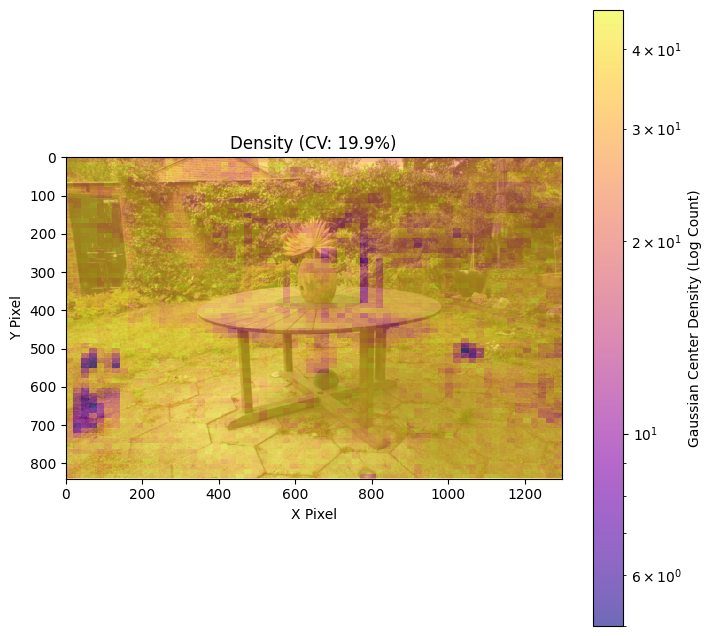

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from PIL import Image
from matplotlib.colors import LogNorm

def plot_centers_heatmap(init_dict_path: Path, target_image: Path = None, bins=64):
    """
    Plots a heatmap of Gaussian centers over a target image and prints 
    numerical density stats to confirm data variation.
    """
    # 1. Load data
    saved = torch.load(init_dict_path, map_location="cpu")
    xy = saved["xy"].numpy()  # [N, 2] in [-1, 1]

    if target_image:
        im = Image.open(target_image)
        W, H = im.size
        
        # 2. Map [-1, 1] coordinates to pixel coords [0, W] and [0, H]
        # MINIMAL UPDATE: Invert Y so +1 (top) maps to 0 (pixel top), and -1 maps to H
        xy_pix = np.zeros_like(xy)
        xy_pix[:, 0] = (xy[:, 0] + 1) * W / 2.0
        xy_pix[:, 1] = (1 - xy[:, 1]) * H / 2.0  # <--- Flipped Y here
        
        # 3. Calculate Histogram Counts Manually for Stats
        counts, xedges, yedges = np.histogram2d(
            xy_pix[:, 0], 
            xy_pix[:, 1], 
            bins=bins, 
            range=[[0, W], [0, H]]
        )
        
        # --- NUMERICAL CHECK START ---
        flat_counts = counts.flatten()
        mean_c = np.mean(flat_counts)
        std_c = np.std(flat_counts)
        max_c = np.max(flat_counts)
        min_c = np.min(flat_counts)
        
        # Coefficient of Variation (CV)
        cv = (std_c / mean_c * 100) if mean_c > 0 else 0
        
        print(f"--- Density Stats (Bins: {bins}x{bins}) ---")
        print(f"Total Points: {len(xy)}")
        print(f"Total est gs params: {len(xy)* 9 }")
        print(f"Total orig param { W * H * 3 }")
        print(f"Param reduction factor:{W * H * 3 / (len(xy)* 9):0.2f} X")
        print(f"Coordinate reduction factor:{W * H / len(xy):0.2f} X")
        print(f"Min Count: {min_c:.0f} | Max Count: {max_c:.0f}")
        print(f"Mean: {mean_c:.2f} | Std Dev: {std_c:.2f}")
        print(f"Variation (CV): {cv:.1f}%")
        
        if cv < 20:
            print("⚠️ WARNING: Low variation. Data is nearly uniform.")
        else:
            print("✅ Data shows significant variation.")
        # --- NUMERICAL CHECK END ---

        # 4. Plotting
        plt.figure(figsize=(8, 8))
        plt.imshow(im)
        
        # Plot the heatmap using the pre-calculated edges, or let hist2d do it again
        # We use LogNorm to help visualize variation if peaks are high
        _, _, _, image = plt.hist2d(
            xy_pix[:, 0],
            xy_pix[:, 1],
            bins=bins,
            range=[[0, W], [0, H]],
            cmap='plasma',
            norm=LogNorm() # Log scale handles outliers better
        )
        
        # Invert the Y-axis of the plot to match image coordinates (0 at top)
        plt.gca().invert_yaxis() # <--- Ensures 0 stays at top for plot axes
        
        image.set_alpha(0.6)
        plt.colorbar(label='Gaussian Center Density (Log Count)')
        plt.title(f"Density (CV: {cv:.1f}%)")
        plt.xlabel("X Pixel")
        plt.ylabel("Y Pixel")
        plt.show()

# Example usage:
plot_centers_heatmap(sample_path, target_image="temp_render.png")

In [ ]:
image_paths = [
    REPO_ROOT / f"Instant-GI/data/kodak/kodim{i:02d}.png" for i in range(1,24)
    # add more file paths to process sequentially
]

start_time = time.time()
for path in image_paths:
    img_tensor = load_image(path)
    gaussians = infer(img_tensor)
    print(f"{path.name}: {gaussians['xy'].shape[0]} Gaussians produced")

duration = time.time() - start_time

print(f"Total time {duration:0.2f}s")
print(f"Avg time {duration / len(image_paths):0.2f}s")


In [ ]:
# run 'hf auth login' and enter your token from huggingface

In [ ]:
import torch
from datasets import load_dataset
from tqdm import tqdm
# No 'numpy' or 'PIL' needed here anymore

def process_imagenet_streaming():
    """
    Streams the ImageNet validation set using Hugging Face 'datasets'
    and gets PyTorch tensors directly.
    """
    print("\nLoading ImageNet-1k validation set from Hugging Face Hub (streaming)...")
    
    try:
        ds = load_dataset(
            "ILSVRC/imagenet-1k", 
            split="validation", 
            streaming=True, 
            #trust_remote_code=False
        )
    except Exception as e:
        print(f"Error loading dataset: {e}")
        print("Please ensure you are logged in via `huggingface-cli login` and have accepted the terms.")
        return

    results = {}
    
    # --- THIS IS THE KEY CHANGE ---
    # Tell the iterator to output PyTorch tensors instead of PIL images.
    ds_torch = ds.with_format("torch")
    # ------------------------------

    for i, sample in enumerate(tqdm(ds_torch, desc="Processing ImageNet (streaming)")):
        try:
            # 1. Get image (now a torch.Tensor)
            # It will have shape [3, H, W] and dtype uint8
            image_tensor_uint8 = sample['image']
            
            # 2. Preprocess the tensor
            # Handle grayscale images that load with 1 channel
            if image_tensor_uint8.shape[0] == 1:
                image_tensor_uint8 = image_tensor_uint8.repeat(3, 1, 1) # [1,H,W] -> [3,H,W]
                
            # Scale from uint8 [0, 255] to float [0.0, 1.0]
            image_tensor_float = image_tensor_uint8 / 255.0
            
            # 3. Run inference
            gaussians = infer(image_tensor_float)
            
            # Store a simple result
            results[i] = gaussians['xy'].shape[0]

        except Exception as e:
            print(f"Error processing image {i}: {e}")
            continue

    print(f"\nImageNet processing complete. Processed {len(results)} images.")
    if results:
        print(f"Sample result (Image 0): {results[0]} Gaussians produced")

In [ ]:
process_imagenet_streaming()

# 2D Gaussian loss functs